   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.5 MB/s eta 0:00:00
📁 Upload directory: /content/uploaded_structures
📁 Output directory: /content/visualization_output

📤 Please upload your PDB and/or PDBQT files (or a ZIP).


Saving Wild-Type TP53 Sequence UniProt.pdb to Wild-Type TP53 Sequence UniProt.pdb
✅ Saved: Wild-Type TP53 Sequence UniProt.pdb

🔍 Found 1 structures.

🧪 Testing rainbow coloring on: Wild-Type TP53 Sequence UniProt.pdb
✅ Test image saved: /content/visualization_output/Wild-Type TP53 Sequence UniProt.png


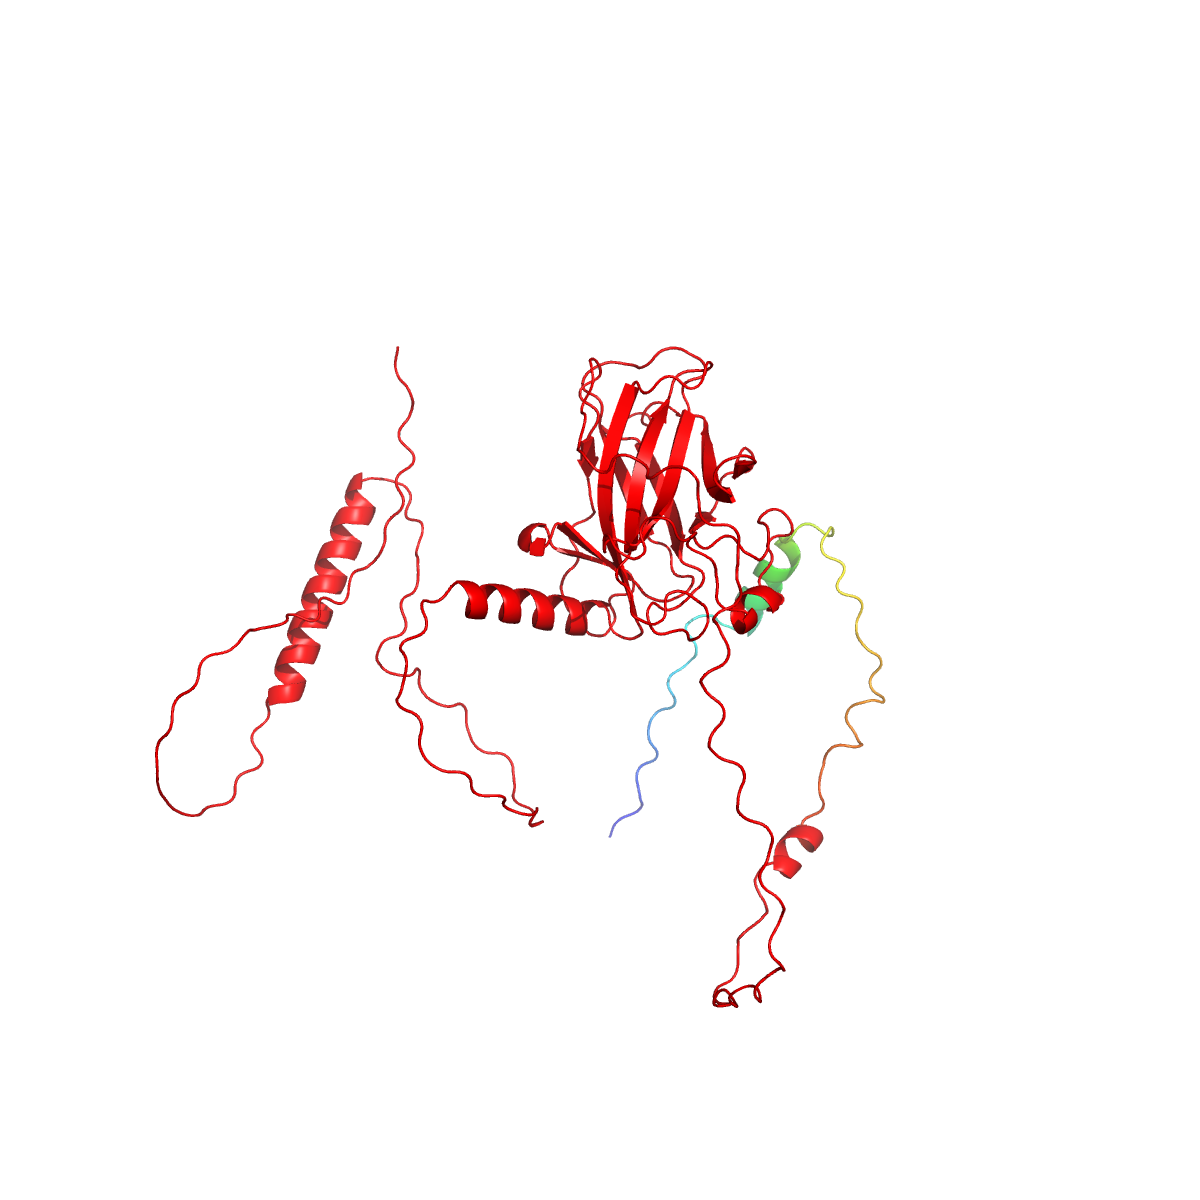


👉 Should show a full rainbow from blue to red, with lots of space around it.

🔄 Generating visualisations for all structures...


Processing: 100%|██████████| 1/1 [00:04<00:00,  4.76s/it]



📊 CSV saved: /content/visualization_output/structure_metadata.csv
📊 Excel saved: /content/visualization_output/structure_metadata.xlsx

📦 Results zipped: /content/visualization_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Your rainbow images (with orient and zoom 25) are ready.


In [1]:
# =============================================================================
# PROTEIN VISUALIZATION PIPELINE – RAINBOW BY RESIDUE (ZOOM 25, with ORIENT)
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Installation
# -----------------------------------------------------------------------------
!apt-get remove -y pymol > /dev/null 2>&1
!apt-get install -y libgl1-mesa-glx libgl1-mesa-dri > /dev/null 2>&1
!pip install -q pymol-open-source biopython pandas openpyxl tqdm

import os
import glob
import zipfile
import subprocess
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser, PPBuilder
from google.colab import files
from tqdm import tqdm

# -----------------------------------------------------------------------------
# 2. Directories
# -----------------------------------------------------------------------------
UPLOAD_DIR = "/content/uploaded_structures"
OUTPUT_DIR = "/content/visualization_output"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Upload directory: {UPLOAD_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")

# -----------------------------------------------------------------------------
# 3. Upload files
# -----------------------------------------------------------------------------
print("\n📤 Please upload your PDB and/or PDBQT files (or a ZIP).")
uploaded = files.upload()

for filename, content in uploaded.items():
    filepath = os.path.join(UPLOAD_DIR, filename)
    with open(filepath, 'wb') as f:
        f.write(content)
    print(f"✅ Saved: {filename}")

# Extract ZIP archives
zip_files = [f for f in os.listdir(UPLOAD_DIR) if f.endswith('.zip')]
for zip_name in zip_files:
    zip_path = os.path.join(UPLOAD_DIR, zip_name)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(UPLOAD_DIR)
    print(f"📦 Extracted: {zip_name}")
    os.remove(zip_path)

# Find all structure files
pdb_files = glob.glob(os.path.join(UPLOAD_DIR, '*.pdb'))
pdbqt_files = glob.glob(os.path.join(UPLOAD_DIR, '*.pdbqt'))

# -----------------------------------------------------------------------------
# 4. Prioritize PDB files for better residue info
# -----------------------------------------------------------------------------
structure_files = []
pdb_bases = {os.path.splitext(os.path.basename(f))[0]: f for f in pdb_files}

for pdbqt in pdbqt_files:
    base = os.path.splitext(os.path.basename(pdbqt))[0]
    if base in pdb_bases:
        structure_files.append(pdb_bases[base])
        print(f"📌 Using PDB for {base}")
    else:
        structure_files.append(pdbqt)
        print(f"⚠️ No PDB found for {base}, using PDBQT")

for base, path in pdb_bases.items():
    if path not in structure_files:
        structure_files.append(path)

if not structure_files:
    raise SystemExit("❌ No structure files found.")

print(f"\n🔍 Found {len(structure_files)} structures.")

# -----------------------------------------------------------------------------
# 5. Helper functions
# -----------------------------------------------------------------------------
def get_sequence_from_pdb(pdb_path):
    parser = PDBParser(QUIET=True)
    try:
        struct = parser.get_structure('protein', pdb_path)
        ppb = PPBuilder()
        seq = "".join(str(pp.get_sequence()) for pp in ppb.build_peptides(struct))
        return seq
    except Exception:
        return ""

def get_plddt_stats(pdb_path):
    parser = PDBParser(QUIET=True)
    try:
        struct = parser.get_structure('protein', pdb_path)
        b_factors = [atom.get_bfactor() for atom in struct.get_atoms()]
        if b_factors:
            return np.mean(b_factors), np.min(b_factors), np.max(b_factors)
    except Exception:
        pass
    return np.nan, np.nan, np.nan

# -----------------------------------------------------------------------------
# 6. Generate images – RAINBOW BY RESIDUE, ZOOM 25, with ORIENT
# -----------------------------------------------------------------------------
def generate_pymol_image(pdb_path, output_dir, zoom_factor=25.0):
    base = os.path.splitext(os.path.basename(pdb_path))[0]
    img_path = os.path.join(output_dir, f"{base}.png")

    # Get sequence length for correct rainbow range
    seq = get_sequence_from_pdb(pdb_path)
    seq_len = len(seq) if seq else 393   # fallback to TP53 length

    pml_script = f"""
load {pdb_path}
hide everything
show cartoon

# --- RESIDUE-BASED RAINBOW (full spectrum) ---
# Colors each residue by its position in the chain.
# Blue at N-terminus, red at C-terminus.
spectrum count, rainbow, all, 1, {seq_len}

# --- Settings for a clean, fully visible image ---
viewport 1200, 1200
orient all
translate [0, 0, 0]
zoom all, {zoom_factor}
bg_color white

# --- Render ---
ray 1200, 1200
png {img_path}
quit
"""
    script_file = "/tmp/script.pml"
    with open(script_file, 'w') as f:
        f.write(pml_script)

    cmd = ['pymol', '-cq', script_file]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️ PyMOL error for {base}: {result.stderr[:200]}")
        return None
    return img_path if os.path.exists(img_path) else None

# -----------------------------------------------------------------------------
# 7. Test on a single file
# -----------------------------------------------------------------------------
TEST_MODE = True
if TEST_MODE and structure_files:
    test_file = next((f for f in structure_files if f.endswith('.pdb')), structure_files[0])
    print(f"\n🧪 Testing rainbow coloring on: {os.path.basename(test_file)}")
    test_img = generate_pymol_image(test_file, OUTPUT_DIR, zoom_factor=25.0)
    if test_img and os.path.exists(test_img):
        print(f"✅ Test image saved: {test_img}")
        from IPython.display import Image, display
        display(Image(test_img))
        print("\n👉 Should show a full rainbow from blue to red, with lots of space around it.")
    else:
        print("❌ Test failed – check your file format.")

# -----------------------------------------------------------------------------
# 8. Batch process all structures
# -----------------------------------------------------------------------------
metadata = []
print("\n🔄 Generating visualisations for all structures...")
for pdb_path in tqdm(structure_files, desc="Processing"):
    base = os.path.splitext(os.path.basename(pdb_path))[0]
    seq = get_sequence_from_pdb(pdb_path)
    mean_plddt, min_plddt, max_plddt = get_plddt_stats(pdb_path)
    img_path = generate_pymol_image(pdb_path, OUTPUT_DIR, zoom_factor=25.0)

    metadata.append({
        'file_name': os.path.basename(pdb_path),
        'base_name': base,
        'sequence_length': len(seq),
        'sequence': seq[:200] + "..." if len(seq) > 200 else seq,
        'mean_plddt': mean_plddt,
        'min_plddt': min_plddt,
        'max_plddt': max_plddt,
        'image_generated': "Yes" if img_path else "No"
    })

# -----------------------------------------------------------------------------
# 9. Save CSV and Excel
# -----------------------------------------------------------------------------
df = pd.DataFrame(metadata)
csv_path = os.path.join(OUTPUT_DIR, "structure_metadata.csv")
excel_path = os.path.join(OUTPUT_DIR, "structure_metadata.xlsx")

df.to_csv(csv_path, index=False, float_format='%.2f')
print(f"\n📊 CSV saved: {csv_path}")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Metadata', index=False, float_format='%.2f')
    summary = {
        'Metric': ['Total structures', 'Mean pLDDT', 'Median pLDDT', 'Min pLDDT', 'Max pLDDT'],
        'Value': [
            len(df),
            df['mean_plddt'].mean(),
            df['mean_plddt'].median(),
            df['min_plddt'].min(),
            df['max_plddt'].max()
        ]
    }
    pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
print(f"📊 Excel saved: {excel_path}")

# -----------------------------------------------------------------------------
# 10. Zip and download
# -----------------------------------------------------------------------------
zip_path = "/content/visualization_results.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for img in glob.glob(os.path.join(OUTPUT_DIR, '*.png')):
        zipf.write(img, os.path.basename(img))
    zipf.write(csv_path, os.path.basename(csv_path))
    zipf.write(excel_path, os.path.basename(excel_path))

print(f"\n📦 Results zipped: {zip_path}")
files.download(zip_path)

print("\n✅ All done! Your rainbow images (with orient and zoom 25) are ready.")